# Introdução

 Este documento traz uma breve discussão do entendimento do aluno frente a atividade
 proposta no laboratório 5. Para a realização de todos os itens da atividade foi desenvolvido um único algoritmo,
 que se encontra em anexo.
 Quanto aos valores escolhidos pelo aluno: a frequência utilizada para a gravação do
 áudio foi de 3.4 kHz, frequência normalmente utilizada em linhas telefônicas segundo o material
 da aula teórica; a taxa de amostragem utilizada no sinal gerado foi de 8 kHz, frequência
 normalmente utilizada para PCM segundo a aula teórica; o áudio gravado trata-se da frase
 “Olá testando”, pronunciada pelo aluno; o tempo de duração do áudio é de 5
 segundos; e o número de bits utilizado para a codificação foi o de 8 bits por amostra, valor
 normalmente utilizado segundo a aula teórica. Demais detalhes serão discutidos a seguir.

Importação das bibliotecas

In [ ]:
import numpy as np
import sounddevice as sd
import soundfile as sf
import matplotlib.pyplot as plt

Leitura do áudio

In [ ]:
arquivo_audio = "gravacao.wav"

try:
    original_audio, fs = sf.read(arquivo_audio)
    print(f"Arquivo '{arquivo_audio}' carregado com sucesso. Fs = {fs} Hz")
except FileNotFoundError:
    raise FileNotFoundError(f"O arquivo '{arquivo_audio}' não foi encontrado no diretório atual.")

# Vetor de tempo
t = np.arange(len(original_audio)) / fs

Arquivo 'gravacao.wav' carregado com sucesso. Fs = 48000 Hz


Gerando gráfico do sinal original

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(t, original_audio)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.xlim([1.1, 3.7])
#plt.xlim([1, 1.5])
plt.title("Sinal Original")
plt.grid(True)
plt.show()

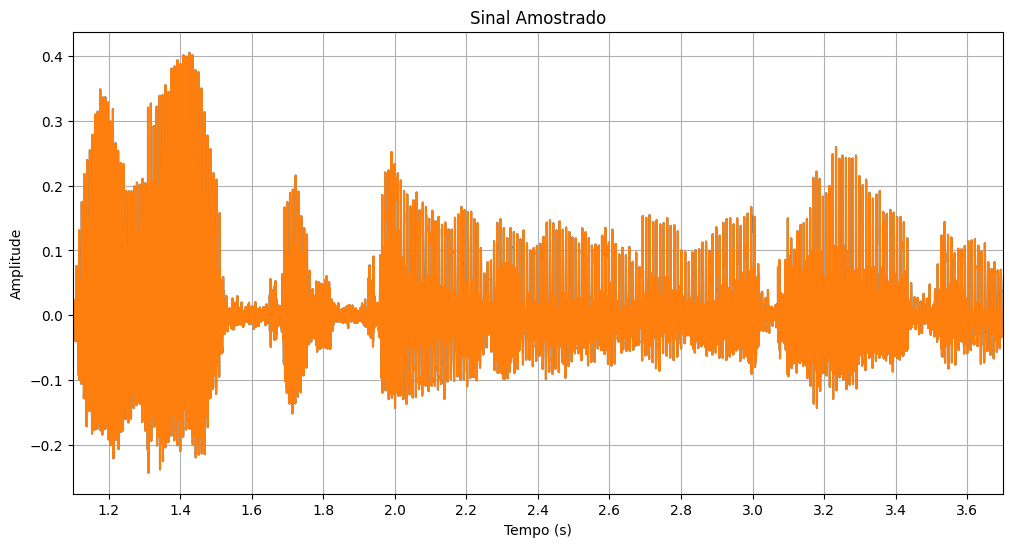

In [ ]:
Fs_amostragem = 48000  # Nova taxa de amostragem

# Seleciona amostras proporcionalmente à taxa
passo = int(fs / Fs_amostragem)
sinal_amostrado = original_audio[::passo]
t_amostrado = np.arange(len(sinal_amostrado)) / Fs_amostragem
# Plot do sinal amostrado
plt.figure(figsize=(12, 6))
plt.plot(t_amostrado, sinal_amostrado)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.yticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.xlim([1.1, 3.7])
#plt.xlim([1, 1.5])
plt.title("Sinal Amostrado")
plt.grid(True)
plt.show()

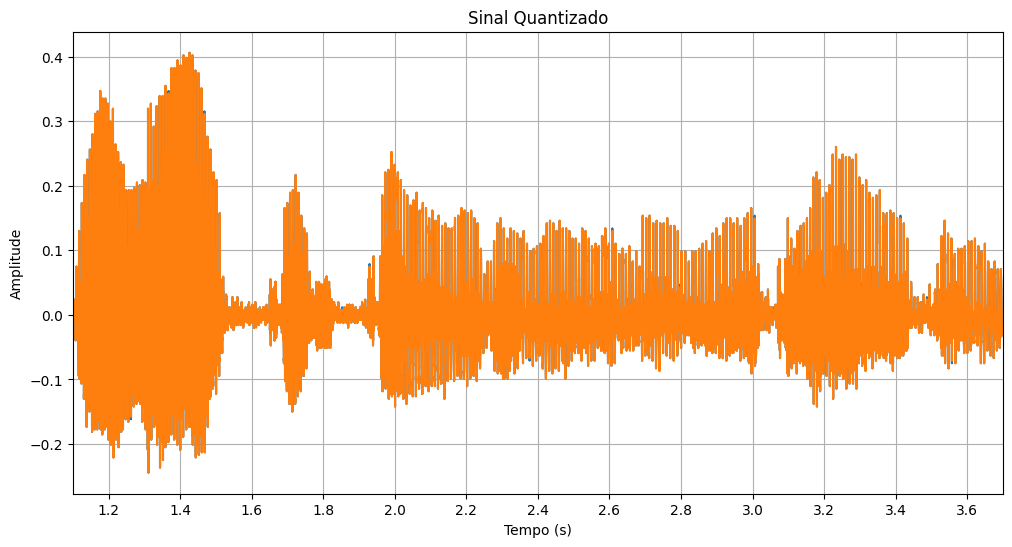

Intervalo de quantização: 0.002535


In [ ]:
num_bits = 8
num_niveis_quantizacao = 2 ** num_bits

# Intervalo de quantização
quantization_range = (np.max(sinal_amostrado) - np.min(sinal_amostrado)) / num_niveis_quantizacao

# Quantização (com arredondamento semelhante ao MATLAB)
sinal_quantizado = np.round(sinal_amostrado * quantization_range * 1e5) / (quantization_range * 1e5)

# Plot do sinal quantizado
plt.figure(figsize=(12, 6))
plt.plot(t_amostrado, sinal_quantizado)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal Quantizado")
plt.xlim([1.1, 3.7])
plt.grid(True)
plt.show()

print(f"Intervalo de quantização: {quantization_range:.6f}")

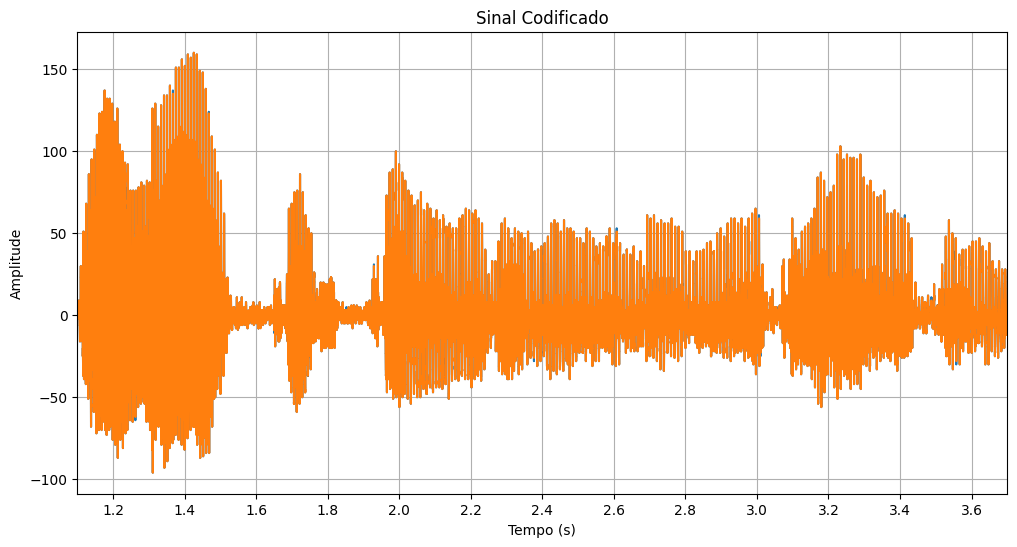

In [ ]:
codificacao = np.round(sinal_quantizado / quantization_range)

# Plot do sinal codificado
plt.figure(figsize=(12, 6))
plt.plot(t_amostrado, codificacao)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal Codificado")
plt.xlim([1.1, 3.7])
plt.grid(True)
plt.show()

In [ ]:
sf.write("amostrado.wav", sinal_amostrado, Fs_amostragem)
sf.write("quantizado.wav", sinal_quantizado, Fs_amostragem)
sf.write("codificado.wav", codificacao / 10, Fs_amostragem)

print("Arquivos salvos: amostrado.wav, quantizado.wav e codificado.wav")


Arquivos salvos: amostrado.wav, quantizado.wav e codificado.wav
